# Pilot coding and competitive-impact audit

This notebook demonstrates the adjudication grain, guideline mapping, and tiered competitive-impact method. Every coded row is an AI-assisted first pass with `review_status=single_coded_pending_human`. Results are **provisional pipeline demonstrations**, not final findings about FIA consistency.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB_PATH = ROOT / 'data' / 'processed' / 'f1_stewarding.duckdb'
CODED_PATH = ROOT / 'data' / 'manual' / 'pilot_coded_adjudications.csv'
IMPACT_PATH = ROOT / 'data' / 'manual' / 'pilot_impact_assessments.csv'

coded = pd.read_csv(CODED_PATH)
impact = pd.read_csv(IMPACT_PATH)
con = duckdb.connect(str(DB_PATH), read_only=True)

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Brian Zeng\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## 1. Review gate

Schema validation catches impossible combinations, duplicate identifiers, missing source lineage, and non-reproducible mechanical arithmetic. It does not certify subjective coding.

In [2]:
review_summary = pd.DataFrame(
    {
        'artifact': ['adjudications', 'impact assessments'],
        'rows': [len(coded), len(impact)],
        'pending_human_review': [
            coded.review_status.eq('single_coded_pending_human').sum(),
            impact.review_status.eq('single_coded_pending_human').sum(),
        ],
    }
)
display(review_summary)
assert review_summary.pending_human_review.eq(review_summary.rows).all()

,artifact,rows,pending_human_review
0,adjudications,9,9
1,impact assessments,4,4


## 2. Event-date regulatory lineage

The governing instrument is versioned at the event level. `applicable_metadata_only` is an explicit source gap: the 2023 Appendix L archive label predates Abu Dhabi, but the current linked binary is a later revision.

In [3]:
regulatory = con.sql('''
SELECT l.event_id, l.event_role, s.document_type, s.publication_date,
       s.applicability_status, s.title, s.source_url
FROM metadata.event_regulatory_sources l
JOIN metadata.regulatory_sources s USING (source_id)
ORDER BY l.event_id, l.event_role, s.document_type
''').df()
display(regulatory)

,event_id,event_role,document_type,publication_date,applicability_status,title,source_url
0,2019-aut,governing,appendix_l_driving_conduct,2019-06-17,applicable_verified,"2019 Appendix L, published 17 June 2019",https://www.fia.com/files/appendixl2019publiel...
1,2019-aut,governing,f1_sporting_regulations,2019-03-12,applicable_verified,"2019 Formula One Sporting Regulations, publish...",https://www.fia.com/sites/default/files/2019_s...
2,2019-aut,governing,international_sporting_code,NaT,applicable_verified,"2019 FIA International Sporting Code, marked-u...",https://www.fia.com/sites/default/files/2019_i...
3,2023-abu,governing,appendix_l_driving_conduct,2023-10-19,applicable_metadata_only,"2023 Appendix L archive entry, published 19 Oc...",https://www.fia.com/appendix-l-international-d...
4,2023-abu,governing,f1_sporting_regulations,2023-10-25,applicable_verified,"2023 Formula One Sporting Regulations, Issue 7",https://www.fia.com/sites/default/files/fia_20...
5,2023-abu,governing,international_sporting_code,2023-01-09,applicable_verified,"2023 FIA International Sporting Code, clean ed...",https://www.fia.com/sites/default/files/2023_i...
6,2025-aut,governing,appendix_l_driving_conduct,2024-12-11,applicable_verified,"2025 Appendix L, published 11 December 2024",https://www.fia.com/sites/default/files/6_-_ap...
7,2025-aut,governing,f1_sporting_regulations,2025-04-30,applicable_verified,"2025 Formula One Sporting Regulations, Issue 5",https://www.fia.com/system/files/documents/fia...
8,2025-aut,governing,international_sporting_code,2025-01-22,applicable_verified,"2025 FIA International Sporting Code, clean ed...",https://www.fia.com/sites/default/files/2025_i...
9,2025-aut,interpretive_guidance,f1_driving_standards_guidelines,2025-02-20,applicable_verified,"2025 Formula 1 Driving Standards Guidelines, V...",https://www.fia.com/sites/default/files/f1_dri...


## 3. Adjudication-level pilot

The analytical unit is one accused driver, not one PDF. The paired 2019 documents therefore become two adjudications linked to one incident.

,event_id,incident_family,outcome_family,adjudications
0,2019-aut,causing_collision,no_further_action,2
1,2023-abu,causing_collision,no_further_action,1
2,2023-abu,causing_collision,time_penalty,1
3,2025-aut,causing_collision,grid_penalty,1
4,2025-aut,causing_collision,time_penalty,1
5,2025-aut,forcing_off_track,no_further_action,2
6,2025-aut,forcing_off_track,time_penalty,1


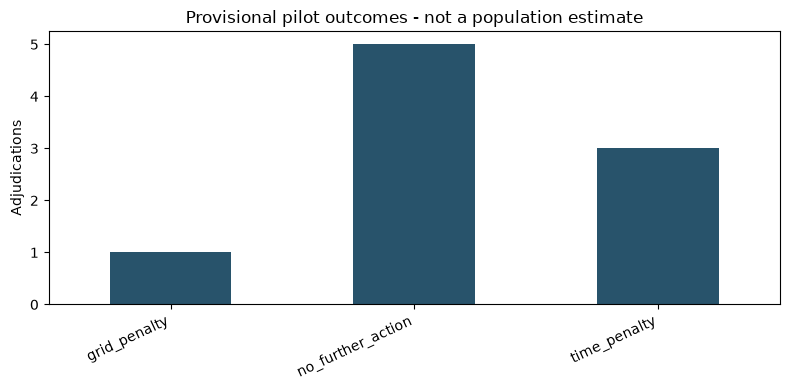

In [4]:
summary = (
    coded.groupby(['event_id', 'incident_family', 'outcome_family'])
    .size()
    .rename('adjudications')
    .reset_index()
)
display(summary)

outcomes = coded.outcome_family.value_counts().sort_index()
ax = outcomes.plot.bar(color='#28536b', figsize=(8, 4))
ax.set(
    title='Provisional pilot outcomes - not a population estimate',
    xlabel='',
    ylabel='Adjudications',
)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

## 4. Public-guideline mapping

Only the 2025 event has public Formula 1 driving and penalty guidelines. Earlier internal driving standards are unavailable, so their conformance is coded `unclear` or `not_applicable` rather than backfilled from 2025.

,adjudication_id,incident_family,outcome_family,guideline_clause,guideline_expected_outcome,conformance_status
4,adj-2025-aut-r31-t4-22,causing_collision,time_penalty,Penalty_2025_AppL_ChIV_2d,10s_baseline_up_to_drive_through_3pp_max,conformant
5,adj-2025-aut-r4-t3-43,forcing_off_track,no_further_action,DSG_4.1_B_outside_overtake,no_infringement_if_outside_car_not_ahead_at_apex,conformant
6,adj-2025-aut-r54-t34-43,forcing_off_track,time_penalty,Penalty_2025_AppL_ChIV_2b,10s_baseline_or_5s_with_mitigation_2pp_max,mitigated
7,adj-2025-aut-r1-t3-12,causing_collision,grid_penalty,Penalty_2025_AppL_ChIV_2d,10s_baseline_or_grid_penalty_if_driver_did_not...,conformant
8,adj-2025-aut-r15-t3-22,forcing_off_track,no_further_action,DSG_4.1_A_inside_overtake,no_infringement_if_inside_car_meets_priority_c...,conformant


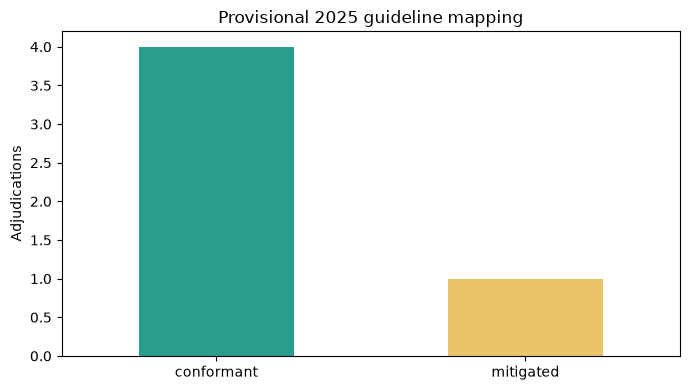

In [5]:
guideline_view = coded.loc[
    coded.event_id.eq('2025-aut'),
    [
        'adjudication_id',
        'incident_family',
        'outcome_family',
        'guideline_clause',
        'guideline_expected_outcome',
        'conformance_status',
    ],
]
display(guideline_view)
guideline_view.conformance_status.value_counts().plot.bar(
    color=['#2a9d8f', '#e9c46a'], figsize=(7, 4)
)
plt.title('Provisional 2025 guideline mapping')
plt.xlabel('')
plt.ylabel('Adjudications')
plt.xticks(rotation=0)
plt.tight_layout()

## 5. Competitive impact

A post-race-added time penalty permits exact same-lap classification arithmetic. A served penalty or next-event grid drop changes strategy or a different event and is not mechanically estimable.

,adjudication_id,impact_level,sanction_application,official_finish_position,counterfactual_finish_position,points_gained_without_penalty,assumptions
0,adj-2023-abu-r47-t6-11,mechanical,post_race_added,4.0,2.0,6.0,The official final table shows the five-second...
1,adj-2025-aut-r54-t34-43,mechanical,post_race_added,15.0,15.0,0.0,The official final table shows Car 43 8.230 se...
2,adj-2025-aut-r31-t4-22,not_estimable,served_during_race,16.0,NaN,NaN,Race Control records the penalty as served. Re...
3,adj-2025-aut-r1-t3-12,not_estimable,next_event_grid,NaN,NaN,NaN,The official table lists Car 12 as not classif...


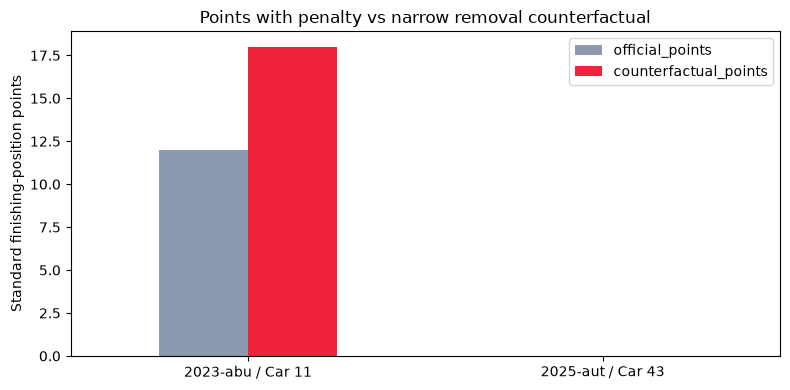

In [6]:
impact_columns = [
    'adjudication_id',
    'impact_level',
    'sanction_application',
    'official_finish_position',
    'counterfactual_finish_position',
    'points_gained_without_penalty',
    'assumptions',
]
display(impact[impact_columns])

mechanical = impact.loc[impact.impact_level.eq('mechanical')].copy()
mechanical['label'] = mechanical.event_id + ' / Car ' + mechanical.driver_number.astype(str)
points = mechanical.set_index('label')[['official_points', 'counterfactual_points']]
ax = points.plot.bar(figsize=(8, 4), color=['#8d99ae', '#ef233c'])
ax.set(
    title='Points with penalty vs narrow removal counterfactual',
    xlabel='',
    ylabel='Standard finishing-position points',
)
plt.xticks(rotation=0)
plt.tight_layout()

In [7]:
classification_crosscheck = con.sql('''
SELECT event_id, driver_number, abbreviation, finish_position, laps_completed,
       classification_gap_seconds, status, points
FROM raw.fastf1_results
WHERE (event_id = '2023-abu' AND driver_number IN (16, 63, 11, 4))
   OR (event_id = '2025-aut' AND driver_number IN (18, 43, 22, 12))
ORDER BY event_id, finish_position
''').df()
display(classification_crosscheck)

,event_id,driver_number,abbreviation,finish_position,laps_completed,classification_gap_seconds,status,points
0,2023-abu,16,LEC,2.0,58.0,17.993,Finished,18.0
1,2023-abu,63,RUS,3.0,58.0,20.328,Finished,15.0
2,2023-abu,11,PER,4.0,58.0,21.453,Finished,12.0
3,2023-abu,4,NOR,5.0,58.0,24.284,Finished,10.0
4,2025-aut,18,STR,14.0,69.0,34.462,Lapped,0.0
5,2025-aut,43,COL,15.0,69.0,42.692,Lapped,0.0
6,2025-aut,22,TSU,16.0,68.0,2.979,Lapped,0.0
7,2025-aut,12,ANT,19.0,1.0,NaN,Retired,0.0


## 6. Interpretation and next decision

The pilot proves that official decisions, event-date rules, timing, Race Control, and final classifications can be joined at an auditable adjudication grain. It also demonstrates why source and counterfactual tiers matter: a five-second label does not imply a universal five-second race effect.

No frequency, consistency, or nationality conclusion can be drawn from these deliberately selected events. Full 2018-2025 collection remains behind the independent-review gate.

In [8]:
con.close()